In [1]:
using Pkg
Pkg.activate("/Users/alia/Desktop/envs/ants")
using Plots
using DifferentialEquations
using LaTeXStrings
using NLsolve
using IntervalArithmetic, IntervalArithmetic.Symbols, IntervalRootFinding
using LinearAlgebra
using Plots.PlotMeasures

  Activating project at `~/Desktop/envs/ants`


In [2]:
pythonplot()

Plots.PythonPlotBackend()

In [3]:
xgfs_normal12 = [(235, 172, 35), (184, 0, 88), (0, 140, 249), (0, 110, 0), (0, 187, 173), (209, 99, 230), (178, 69, 2), (255, 146, 135), (89, 84, 214), (0, 198, 248), (135, 133, 0), (0, 167, 108), (189, 189, 189)]
pal = [RGB(r/255, g/255, b/255) for (r,g,b) in xgfs_normal12]
#pal = palette

### SIS style version
with reinfection rate $\gamma$

In [4]:
function softmax(x)
    ex = exp.(x)
    return ex ./ (sum(ex))
end

function normal(x)
    return (x .+ 1) / (sum(x)+size(x)[1])
end

function model_7d!(dx,x,p,t)
    (alphaC,alphaB,alphaT,beta,omegaC,omegaB,k,
    n,u,aC,aB,aT,aBC,aTC,bC,aCB,aTB,bB,aCT,aBT,bT,tau,gamma,b0C,b0B,b0T)=p
    S,C,B,T,xC,xB,xT = x
    H = 1 - S - B - C - T
    dx[1] = (-(alphaC*(1+xC)+alphaB*(1+xB)+alphaT*(1+xT))*S) + gamma*H
    dx[2] = alphaC*(1+xC)*S - omegaC*C/(1+ (C/k)^n)
    dx[3] = alphaB*(1+xB)*S - omegaB*B/(1+ (C/k)^n)
    dx[4] = alphaT*(1+xT)*S - beta*T
    dx[5] = 1/tau*(-xC + tanh(u*(aC*xC + aBC*xB + aTC*xT + bC*C) + b0C))
    dx[6] = 1/tau*(-xB + tanh(u*(aB*xB + aCB*xC + aTB*xT + bB*C) + b0B))
    dx[7] = 1/tau*(-xT + tanh(u*(aT*xT + aCT*xC + aBT*xB + bT*C) + b0T))
    return nothing
end

function model_7d_softmax!(dx,x,p,t)
    (alphaC,alphaB,alphaT,beta,omegaC,omegaB,k,
    n,u,aC,aB,aT,aBC,aTC,bC,aCB,aTB,bB,aCT,aBT,bT,tau,gamma,b0C,b0B,b0T)=p
    S,C,B,T,xC,xB,xT = x
    H = 1 - S - B - C - T
    xCn,xBn,xTn = softmax([xC,xB,xT])
    dx[1] = (-(alphaC*xCn+alphaB*xBn+alphaT*xTn)*S) + gamma*H
    dx[2] = alphaC*xCn*S - omegaC*C/(1+ (C/k)^n)
    dx[3] = alphaB*xBn*S - omegaB*B/(1+ (C/k)^n)
    dx[4] = alphaT*xTn*S - beta*T
    dx[5] = 1/tau*(-xC + tanh(u*(aC*xC + aBC*xB + aTC*xT + bC*C) + b0C))
    dx[6] = 1/tau*(-xB + tanh(u*(aB*xB + aCB*xC + aTB*xT + bB*C) + b0B))
    dx[7] = 1/tau*(-xT + tanh(u*(aT*xT + aCT*xC + aBT*xB + bT*C) + b0T))
    return nothing
end

function model_7d_avg!(dx,x,p,t)
    (alphaC,alphaB,alphaT,beta,omegaC,omegaB,k,
    n,u,aC,aB,aT,aBC,aTC,bC,aCB,aTB,bB,aCT,aBT,bT,tau,gamma,b0C,b0B,b0T)=p
    S,C,B,T,xC,xB,xT = x
    H = 1 - S - B - C - T
    xCn,xBn,xTn = normal([xC,xB,xT])
    dx[1] = (-(alphaC*xCn+alphaB*xBn+alphaT*xTn)*S) + gamma*H
    dx[2] = alphaC*xCn*S - omegaC*C/(1+ (C/k)^n)
    dx[3] = alphaB*xBn*S - omegaB*B/(1+ (C/k)^n)
    dx[4] = alphaT*xTn*S - beta*T
    dx[5] = 1/tau*(-xC + tanh(u*(aC*xC + aBC*xB + aTC*xT + bC*C) + b0C))
    dx[6] = 1/tau*(-xB + tanh(u*(aB*xB + aCB*xC + aTB*xT + bB*C) + b0B))
    dx[7] = 1/tau*(-xT + tanh(u*(aT*xT + aCT*xC + aBT*xB + bT*C) + b0T))
    return nothing
end

function gimmie_gamma_norm(t)
    gamma = 0
    if t>100 && t < 150
        gamma = 1
    #elseif t>170 && t<200
    #    gamma = 1
    else
        gamma = 0
    end

    return gamma
end

function model_7d_sin!(dx,x,p,t)
    (alphaC,alphaB,alphaT,beta,omegaC,omegaB,k,
    n,u,aC,aB,aT,aBC,aTC,bC,aCB,aTB,bB,aCT,aBT,bT,tau,gamma)=p
    S,C,B,T,xC,xB,xT = x
    H = 1 - S - B - C - T
    dx[1] = (-(alphaC*(1+xC)+alphaB*(1+xB)+alphaT*(1+xT))*S) + gamma*H*gimmie_gamma_norm(t)
        # + beta*T + (omegaC*C+omegaB*B)/(1+ (C/k)^n))
    dx[2] = alphaC*(1+xC)*S - omegaC*C/(1+ (C/k)^n)
    dx[3] = alphaB*(1+xB)*S - omegaB*B/(1+ (C/k)^n)
    dx[4] = alphaT*(1+xT)*S - beta*T
    dx[5] = 1/tau*(-xC + tanh(u*(aC*xC + aBC*xB + aTC*xT + bC*C)))
    dx[6] = 1/tau*(-xB + tanh(u*(aB*xB + aCB*xC + aTB*xT + bB*C)))
    dx[7] = 1/tau*(-xT + tanh(u*(aT*xT + aCT*xC + aBT*xB + bT*C)))
    return nothing
end

function model_4d!(dx,x,p,t)
    (alphaC,alphaB,alphaT,beta,omegaC,omegaB,k,
    n,u,aC,aB,aT,aBC,aTC,bC,aCB,aTB,bB,aCT,aBT,bT,tau,gamma)=p
    S,C,B,T = x
    H = 1 - S - B - C - T
    dx[1] = (-(alphaC+alphaB+alphaT)*S) + gamma*H
    dx[2] = alphaC*S - omegaC*C/(1+ (C/k)^n)
    dx[3] = alphaB*S - omegaB*B/(1+ (C/k)^n)
    dx[4] = alphaT*S - beta*T
    #HHdot = H
    return nothing
end

model_4d! (generic function with 1 method)

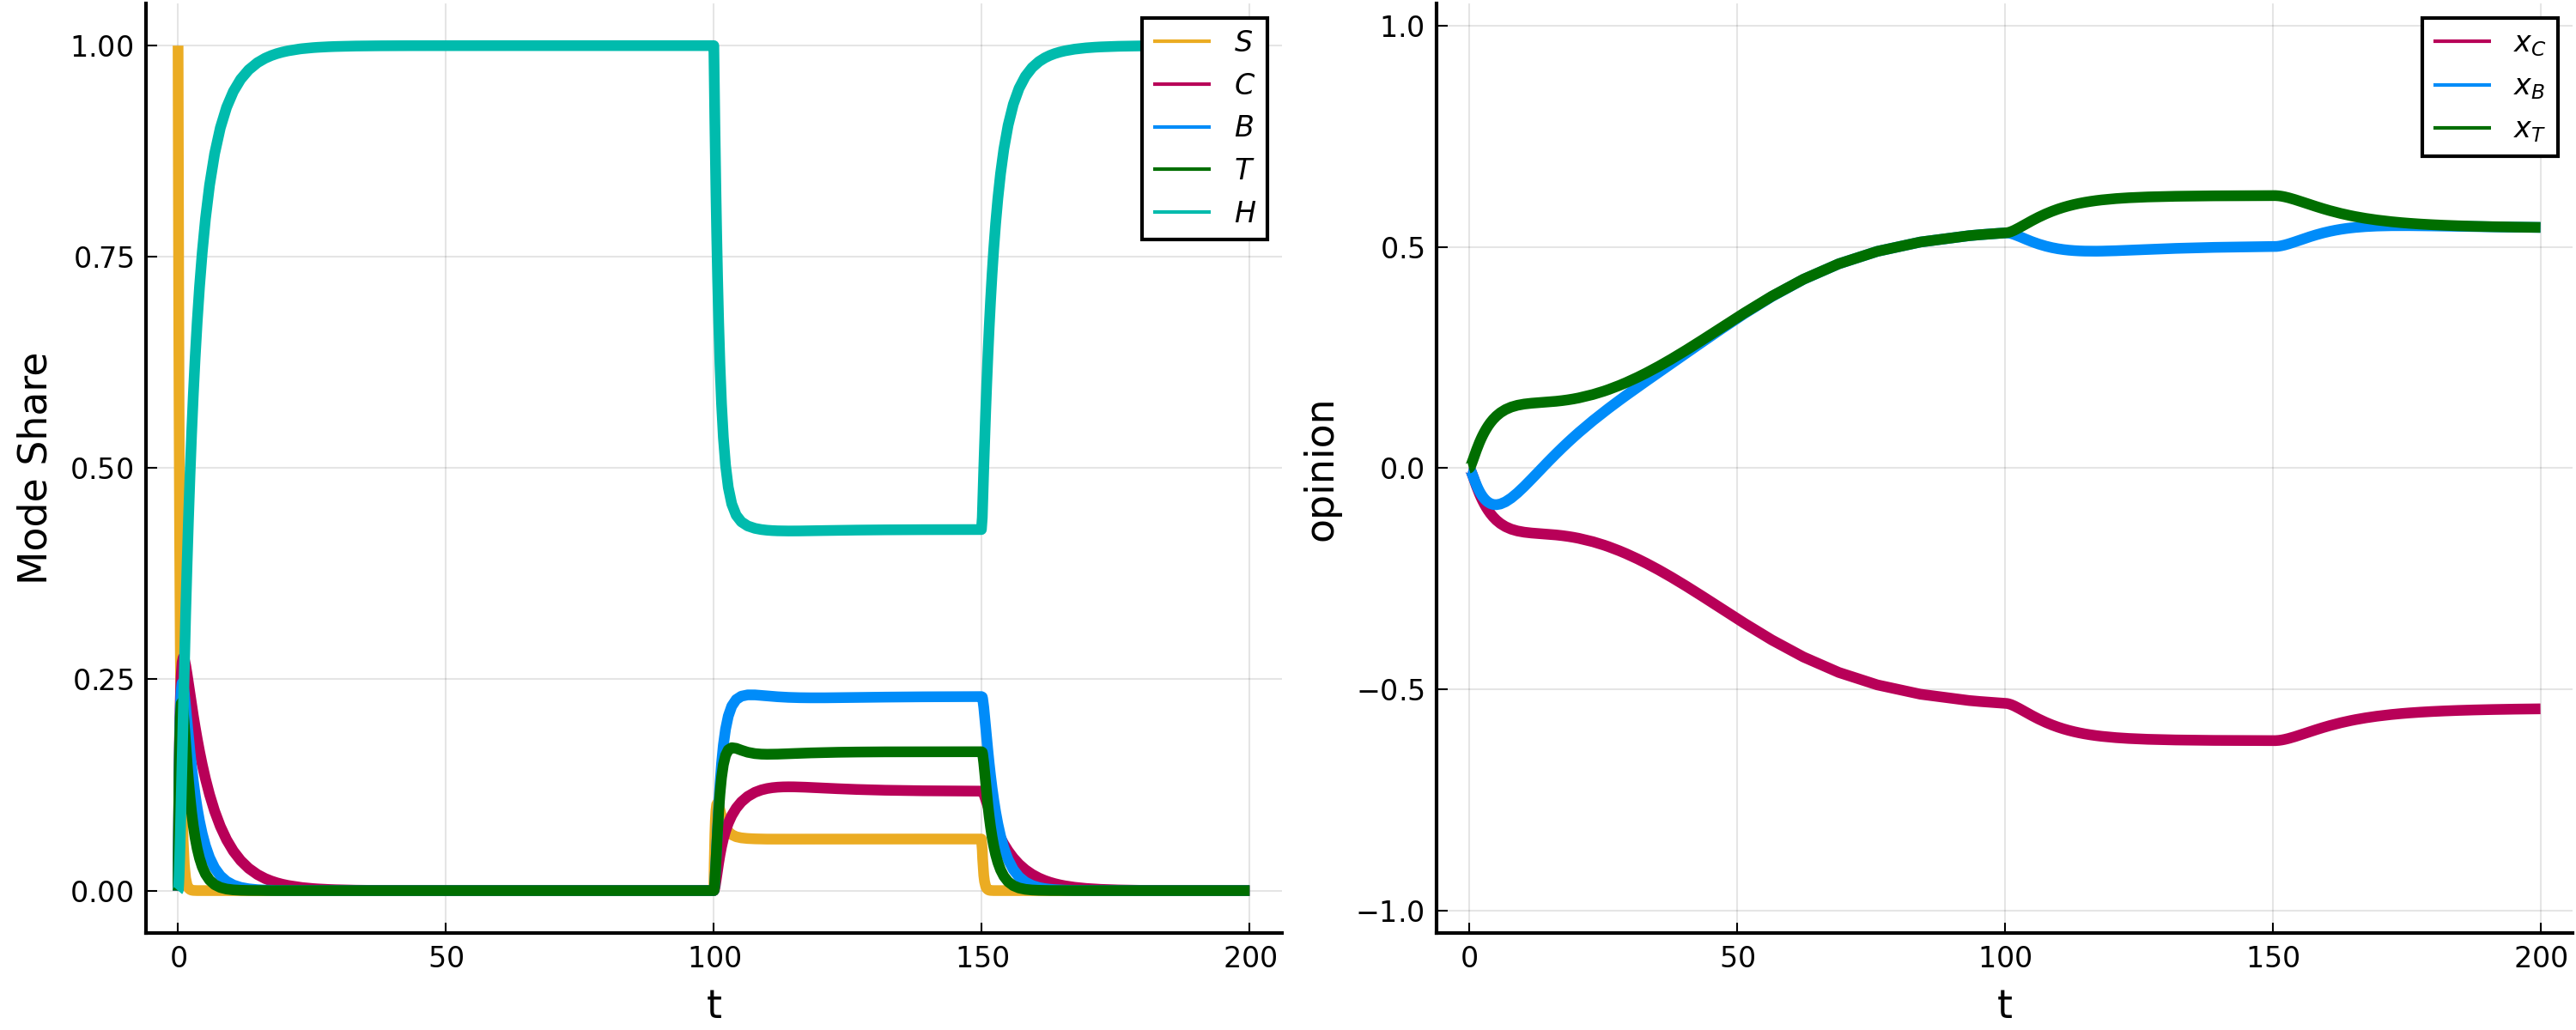

In [5]:
par = (alphaC=1.0,alphaB=1.0,alphaT=1.0,beta=0.6,omegaC=0.2,omegaB=0.4,
     k=0.5,n=4,u=0.8,aC=1.0,aB=1.0,aT=1.0,aBC=-0.2,aTC=-0.2,bC=-0.5,
     aCB=-0.2,aTB=0.2,bB=-0.5,aCT=-0.2,aBT=0.2,bT=0.5,tau = 3,gamma = 0.5)
alphaC,alphaB,alphaT,beta,omegaC,omegaB,k,n,u,aC,aB,aT,aBC,aTC,bC,aCB,aTB,bB,aCT,aBT,bT,tau = par
u0 = [1.0,0.0,0.0,0.0,0.0, 0.0,0.0]
tspan=(0.0,200.0)

prob_7d = ODEProblem(model_7d_sin!,u0,tspan,par)
sol7d = DifferentialEquations.solve(prob_7d)
S,C,B,T,xC,xB,xT = sol7d[1,:],sol7d[2,:],sol7d[3,:],sol7d[4,:],sol7d[5,:],sol7d[6,:],sol7d[7,:]
H = 1 .- S .- C .- B .-T

p1 = plot(sol7d.t, vec(S), label = L"S",  lw=3, ylims=(-0.05,1.05), color = pal[1],xlabel = "t",ylabel = "Mode Share")
plot!(p1, sol7d.t, vec(C), label = L"C",   lw=3, color = pal[2])
plot!(p1, sol7d.t, vec(B), label = L"B",   lw=3, color = pal[3])
plot!(p1, sol7d.t, vec(T), label = L"T",   lw=3, color = pal[4])
plot!(p1, sol7d.t, vec(H), label = L"H",   lw=3, color = pal[5])

p2 = plot(sol7d.t, vec(xC), label = L"x_C", lw=3, ylims=(-1.05,1.05), color = pal[2],xlabel ="t",ylabel = "opinion")
plot!(p2, sol7d.t, vec(xB), label = L"x_B", lw=3, color = pal[3])
plot!(p2, sol7d.t, vec(xT), label = L"x_T", lw=3, color = pal[4])

FIG = plot(p1, p2, size=(1000,400),dpi = 300,left_margin = 5mm)
#png(FIG,"temporary_gamma")

┌ Warning: Could not infer the return type of the function (it may be type instable). Got Any
└ @ IntervalRootFinding /Users/alia/.julia/packages/IntervalRootFinding/U9NQG/src/roots.jl:69


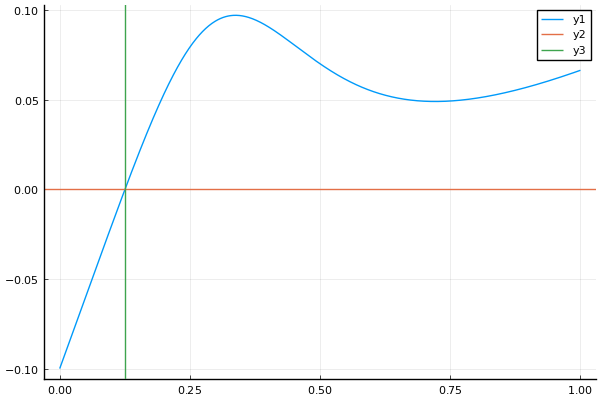

In [6]:
par = (alphaC=1.0,alphaB=1.0,alphaT=1.0,beta=0.6,omegaC=0.2,omegaB=0.4,
     k=0.4,n=4,u=0.8,aC=1.0,aB=1.0,aT=1.0,aBC=-0.2,aTC=-0.2,bC=-0.5,
     aCB=-0.2,aTB=0.2,bB=-0.5,aCT=-0.2,aBT=0.2,bT=0.5,tau = 3,gamma = 0.1) # set k to 0.25 to see hysteresis
alphaC,alphaB,alphaT,beta,omegaC,omegaB,k,n,u,aC,aB,aT,aBC,aTC,bC,aCB,aTB,bB,aCT,aBT,bT,tau,gamma = par
A = omegaC/alphaC * (alphaC + alphaB + alphaT + gamma + gamma*alphaT/beta)
D = gamma * (1 + (omegaC*alphaB)/(omegaB*alphaC))

function equilibrium(C)
    return float(A*(C/(1 + (C/k)^n)) - gamma + D*C)
end

C_star =[]
roots_sol = roots(equilibrium,0..1)
for result in roots_sol
    if result.status == :unique
        push!(C_star,0.5 * (sup(result.region) +inf(result.region)))
    end
end

x = range(0.0, 1, length=1000)
y = @. equilibrium(x)

plot(x,y)
hline!([0])
vline!([C_star])

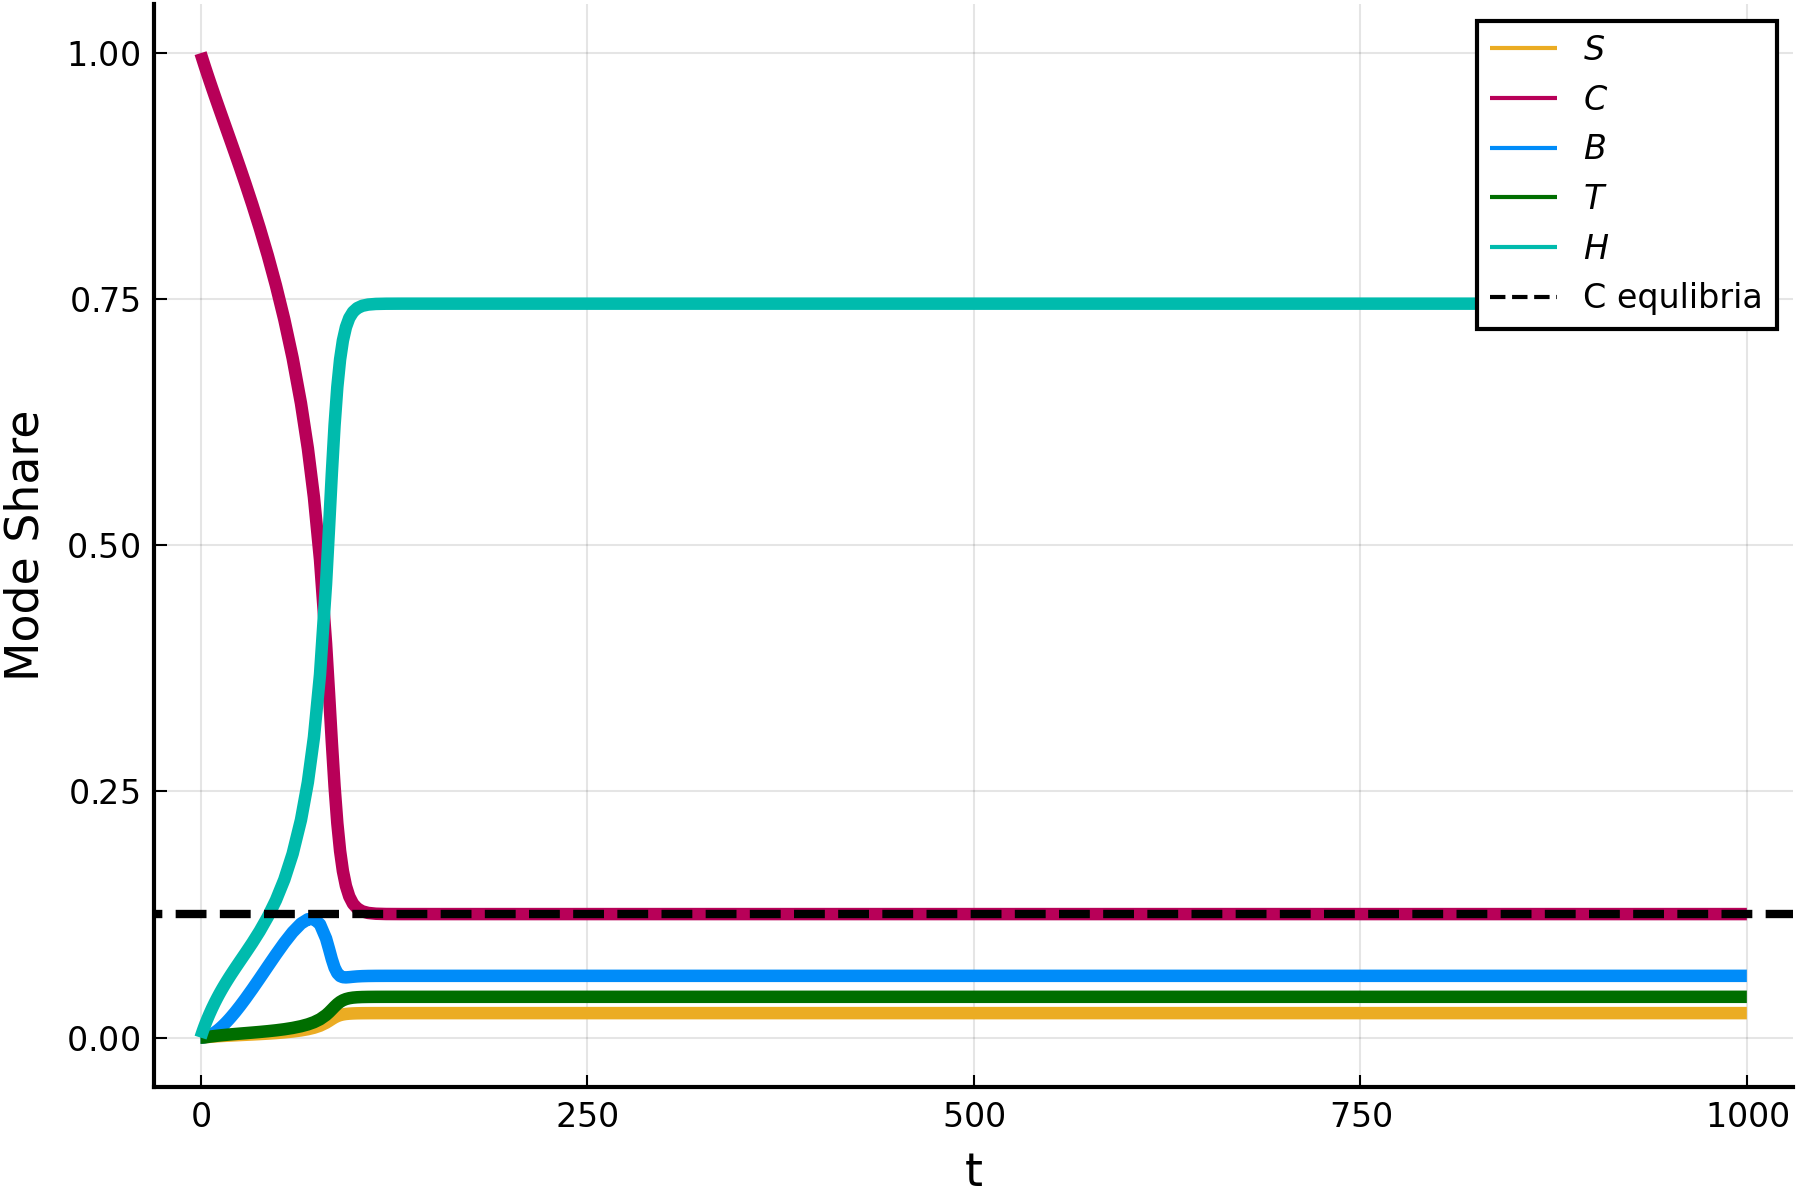

In [7]:
#par = (alphaC=1.0,alphaB=1.0,alphaT=1.0,beta=0.6,omegaC=0.2,omegaB=0.4,k=0.4,n=4,u=0.8,aC=1.0,aB=1.0,aT=1.0,aBC=-0.2,aTC=-0.2,bC=-0.5,aCB=-0.2,aTB=0.2,bB=-0.5,aCT=-0.2,aBT=0.2,bT=0.5,tau = 3,gamma = 0.1)

u0 = [0.0,1.0,0.0,0.0]
tspan=(0.0,1000.0)

prob_4d = ODEProblem(model_4d!,u0,tspan,par)
sol4d = DifferentialEquations.solve(prob_4d)
S,C,B,T = sol4d[1,:],sol4d[2,:],sol4d[3,:],sol4d[4,:]
H = 1 .- S .- C .- B .-T

p1 = plot(sol4d.t, vec(S), label = L"S",  lw=3, ylims=(-0.05,1.05), color = pal[1],xlabel = "t",ylabel = "Mode Share",dpi=300)
plot!(p1, sol4d.t, vec(C), label = L"C",   lw=3, color = pal[2])
plot!(p1, sol4d.t, vec(B), label = L"B",   lw=3, color = pal[3])
plot!(p1, sol4d.t, vec(T), label = L"T",   lw=3, color = pal[4])
plot!(p1, sol4d.t, vec(H), label = L"H",   lw=3, color = pal[5])
hline!(C_star, label = "C equlibria", linestyle = :dash,lw = 2, color = "black")

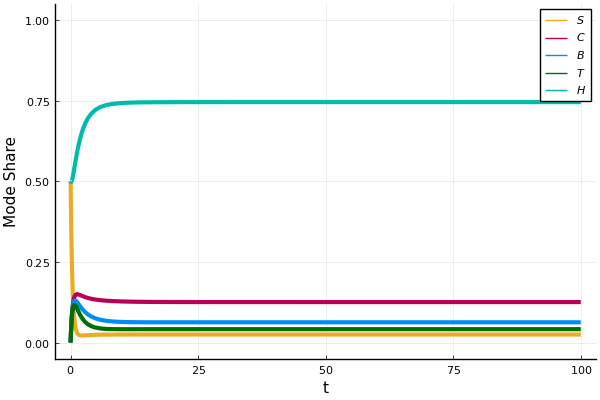

In [8]:
par = (alphaC=1.0,alphaB=1.0,alphaT=1.0,beta=0.6,omegaC=0.2,omegaB=0.4,
     k=0.4,n=4,u=0.8,aC=1.0,aB=1.0,aT=1.0,aBC=-0.2,aTC=-0.2,bC=-0.5,
     aCB=-0.2,aTB=0.2,bB=-0.5,aCT=-0.2,aBT=0.2,bT=0.5,tau = 3,gamma = 0.1)
alphaC,alphaB,alphaT,beta,omegaC,omegaB,k,n,u,aC,aB,aT,aBC,aTC,bC,aCB,aTB,bB,aCT,aBT,bT,tau,gamma = par
u0 = [0.5,0.0,0.0,0.0]
tspan=(0.0,100.0)

prob_4d = ODEProblem(model_4d!,u0,tspan,par)
sol4d = DifferentialEquations.solve(prob_4d)
S4,C4,B4,T4 = sol4d[1,:],sol4d[2,:],sol4d[3,:],sol4d[4,:]
H4 = 1 .- S4 .- C4 .- B4 .-T4

p1 = plot(sol4d.t, vec(S4), label = L"S",  lw=3, ylims=(-0.05,1.05), color = pal[1],xlabel = "t",ylabel = "Mode Share")
plot!(p1, sol4d.t, vec(C4), label = L"C",   lw=3, color = pal[2])
plot!(p1, sol4d.t, vec(B4), label = L"B",   lw=3, color = pal[3])
plot!(p1, sol4d.t, vec(T4), label = L"T",   lw=3, color = pal[4])
plot!(p1, sol4d.t, vec(H4), label = L"H",   lw=3, color = pal[5])

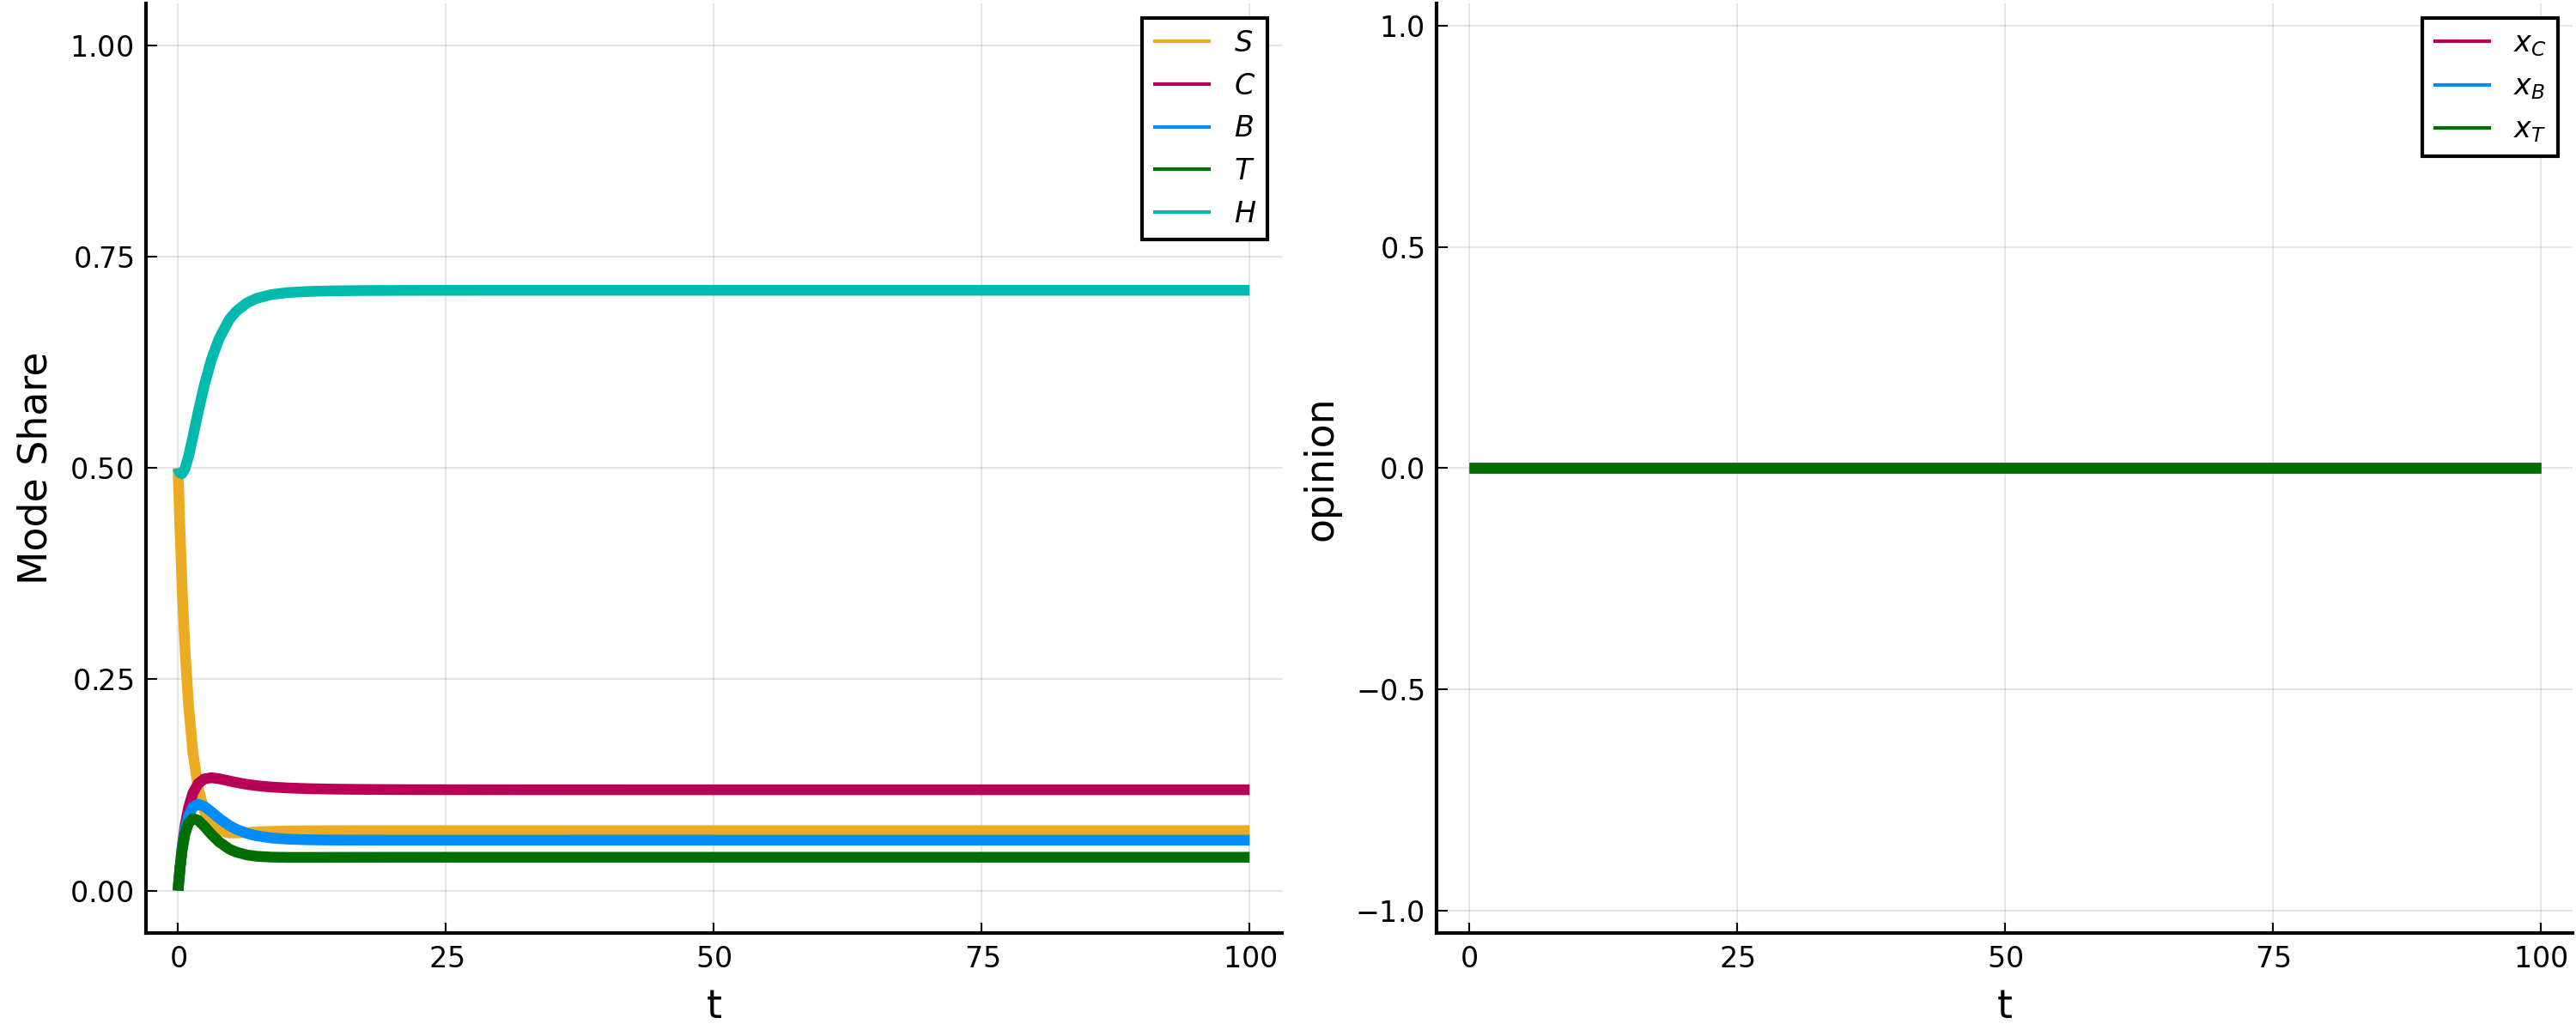

In [9]:
par = (alphaC=1.0,alphaB=1.0,alphaT=1.0,beta=0.6,omegaC=0.2,omegaB=0.4,
     k=0.4,n=4,u=0.0,aC=1.0,aB=1.0,aT=1.0,aBC=-0.2,aTC=-0.2,bC=-1.0,
     aCB=-0.2,aTB=0.2,bB=-1.0,aCT=-0.2,aBT=0.2,bT=1.0,tau = 1,gamma = 0.1,b0C=0.00,b0B=0,b0T=0) # b0C = 0.1026
alphaC,alphaB,alphaT,beta,omegaC,omegaB,k,n,u,aC,aB,aT,aBC,aTC,bC,aCB,aTB,bB,aCT,aBT,bT,tau,gamma,b0C,b0B,b0T = par


u0 = [0.0,0.0,0.0,0.0,-1.0,1.0,1.0]
u0 = [0.5,0,0,0,0,0,0]
#u0 = [0,0.5,0.0,0.0, -1,1,1]

prob_7d = ODEProblem(model_7d_avg!,u0,tspan,par)
sol7d = DifferentialEquations.solve(prob_7d)
S,C,B,T,xC,xB,xT = sol7d[1,:],sol7d[2,:],sol7d[3,:],sol7d[4,:],sol7d[5,:],sol7d[6,:],sol7d[7,:]
H = 1 .- S .- C .- B .-T

p1 = plot(sol7d.t, vec(S), label = L"S",  lw=3, ylims=(-0.05,1.05), color = pal[1],xlabel = "t",ylabel = "Mode Share")
plot!(p1, sol7d.t, vec(C), label = L"C",   lw=3, color = pal[2])
plot!(p1, sol7d.t, vec(B), label = L"B",   lw=3, color = pal[3])
plot!(p1, sol7d.t, vec(T), label = L"T",   lw=3, color = pal[4])
plot!(p1, sol7d.t, vec(H), label = L"H",   lw=3, color = pal[5])

p2 = plot(sol7d.t, vec(xC), label = L"x_C", lw=3, ylims=(-1.05,1.05), color = pal[2],xlabel ="t",ylabel = "opinion")
plot!(p2, sol7d.t, vec(xB), label = L"x_B", lw=3, color = pal[3])
plot!(p2, sol7d.t, vec(xT), label = L"x_T", lw=3, color = pal[4])

FIG = plot(p1, p2, size=(1000,400),dpi = 300,left_margin = 5mm)
#png(FIG,"access")

In [10]:
println(S[end],",",B[end],",",C[end],",",T[end],",",xC[end],",",xB[end],",",xT[end])

0.07104610017650795,0.05967430525743901,0.1193486180517252,0.03947004328837775,0.0,0.0,0.0


In [ ]:
function trapz(x,y)
    N = length(x)
    I = sum([(x[i]-x[i-1])*(y[i-1]+y[i])/2 for i in 2:N])
    return I
end

println(trapz([1,2,3,4,5],[1,4,9,16,25])) # should return 42 if working correctly

# possible cost functions. Reward "happy" H and penalize cars

function costlin(x,H,C,a1,a2)
    return -(-a1*trapz(x,H) + a2*trapz(x,C))/(x[end]-x[1])
end

function costquad(x,H,C,a1,a2)
    return -(-a1*trapz(x,H.^2) + a2*trapz(x,C.^2))/(x[end]-x[1])
end

function costmult(x,H,C)
    return -trapz(x,H .* (1 .- C))/(x[end]-x[1])
end

function costlinparam(x,H,C,a1,a2,a3,alphaC,alphaB,alphaT)
    return -(-a1*trapz(x,H) + a2*trapz(x,C))/(x[end]-x[1]) + a3*(alphaC+alphaB+alphaT)
end

function costlinparamNOD(x,H,C,a1,a2,a3,alphaC,alphaB,alphaT,xC,xB,xT)
    return -(-a1*trapz(x,H) + a2*trapz(x,C) + a3 * trapz(x,(alphaC*(1 .+ xC) + alphaB*(1 .+ xB) + alphaT*(1 .+ xT))))/(x[end]-x[1])
end

function costlinu(x,H,C,a1,a2,a3,u)
    return (a1*trapz(x,H) - a2*trapz(x,C))/(x[end]-x[1]) - a3 * u
end

function costquadu(x,H,C,a1,a2,a3,u)
    return (a1*trapz(x,H.^2) - a2*trapz(x,C.^2))/(x[end]-x[1]) - a3 * u.^2
end


a1 = 1 # happy
a2 = 1 # car
a3 = 0.25 # u
println((alphaC+alphaB+alphaT))
#println(costlinparamNOD(sol7d.t,H,C,a1,a2,a3,alphaC,alphaB,alphaT,xC,xB,xT))

42.0
3.0


In [12]:
println(costlin(sol4d.t,H4,C4,a1,a2))
println(costquad(sol4d.t,H4,C4,a1,a2))
println(costmult(sol4d.t,H4,C4))
println(costlinparam(sol4d.t,H4,C4,a1,a2,a3,alphaC,alphaB,alphaT))

0.61358238506662
0.5320927264161038
-0.646432258677919
1.36358238506662


In [13]:
println(costlin(sol7d.t,H,C,a1,a2))
println(costquad(sol7d.t,H,C,a1,a2))
println(costmult(sol7d.t,H,C))
#println(costlinparam(sol7d.t,H,C,a1,a2,a3,alphaC,alphaB,alphaT))
println(costlinparamNOD(sol7d.t,H,C,a1,a2,a3,alphaC,alphaB,alphaT,xC,xB,xT))

0.584361041734323
0.4818985183702372
-0.6196331573047043
-0.165638958265677


In [14]:
function model_7d_in_out_avg!(dx,x,p,t)
    (alphaC,alphaB,alphaT,beta,omegaC,omegaB,k,
    n,u,aC,aB,aT,aBC,aTC,bC,aCB,aTB,bB,aCT,aBT,bT,tau,gamma)=p
    S,C,B,T,xC,xB,xT = x
    H = 1 - S - B - C - T
    xCn,xBn,xTn = normal([xC,xB,xT])
    dx[1] = (-(alphaC*xCn+alphaB*xBn+alphaT*xTn)*S) + gamma*H
        # + beta*T + (omegaC*C+omegaB*B)/(1+ (C/k)^n))
    dx[2] = alphaC*xCn*S - omegaC*C/(1+ (C/k)^n)
    dx[3] = alphaB*xBn*S - omegaB*B/(1+ (C/k)^n)
    dx[4] = alphaT*xTn*S - beta*T
    dx[5] = 1/tau*(-xC + tanh(u*(aC*xC + aBC*xB + aTC*xT + bC*C)))
    dx[6] = 1/tau*(-xB + tanh(u*(aB*xB + aCB*xC + aTB*xT + bB*C)))
    dx[7] = 1/tau*(-xT + tanh(u*(aT*xT + aCT*xC + aBT*xB + bT*C)))
    dx[8] = gamma*H
    dx[9] = (omegaC*C + omegaB*B)/(1+ (C/k)^n) + beta*T
    return nothing
end

function model_7d_in_out_softmax!(dx,x,p,t)
    (alphaC,alphaB,alphaT,beta,omegaC,omegaB,k,
    n,u,aC,aB,aT,aBC,aTC,bC,aCB,aTB,bB,aCT,aBT,bT,tau,gamma)=p
    S,C,B,T,xC,xB,xT = x
    H = 1 - S - B - C - T
    xCn,xBn,xTn = softmax([xC,xB,xT])
    dx[1] = (-(alphaC*xCn+alphaB*xBn+alphaT*xTn)*S) + gamma*H
        # + beta*T + (omegaC*C+omegaB*B)/(1+ (C/k)^n))
    dx[2] = alphaC*xCn*S - omegaC*C/(1+ (C/k)^n)
    dx[3] = alphaB*xBn*S - omegaB*B/(1+ (C/k)^n)
    dx[4] = alphaT*xTn*S - beta*T
    dx[5] = 1/tau*(-xC + tanh(u*(aC*xC + aBC*xB + aTC*xT + bC*C)))
    dx[6] = 1/tau*(-xB + tanh(u*(aB*xB + aCB*xC + aTB*xT + bB*C)))
    dx[7] = 1/tau*(-xT + tanh(u*(aT*xT + aCT*xC + aBT*xB + bT*C)))
    dx[8] = gamma*H
    dx[9] = (omegaC*C + omegaB*B)/(1+ (C/k)^n) + beta*T
    return nothing
end


function model_4d_in_out!(dx,x,p,t)
    (alphaC,alphaB,alphaT,beta,omegaC,omegaB,k,
    n,u,aC,aB,aT,aBC,aTC,bC,aCB,aTB,bB,aCT,aBT,bT,tau,gamma)=p
    S,C,B,T = x
    H = 1 - S - B - C - T
    dx[1] = (-(alphaC+alphaB+alphaT)*S) + gamma*H
    dx[2] = alphaC*S - omegaC*C/(1+ (C/k)^n)
    dx[3] = alphaB*S - omegaB*B/(1+ (C/k)^n)
    dx[4] = alphaT*S - beta*T
    dx[5] = gamma*H
    dx[6] = (omegaC*C + omegaB*B)/(1+ (C/k)^n) + beta*T
    return nothing
end

model_4d_in_out! (generic function with 1 method)

In [15]:
# par = (alphaC=5.0,alphaB=1.0,alphaT=1.0,beta=0.6,omegaC=0.2,omegaB=0.4,
#     k=0.5,n=4,u=0.4,aC=1.0,aB=1.0,aT=1.0,aBC=-0.2,aTC=-0.2,bC=-0.5,
#     aCB=-0.2,aTB=0.2,bB=-0.5,aCT=-0.2,aBT=0.2,bT=0.5,tau = 3,gamma = 0.1)

par = (alphaC= 1/3 * 1.0,alphaB= 1/3 * 1.0,alphaT= 1/3 * 1.0,beta=0.6,omegaC=0.2,omegaB=0.2,
    k=0.4,n=4,u=1.0,aC=1.0,aB=1.0,aT=1.0,aBC=-0.1,aTC=-0.1,bC=-0.5,
    aCB=-0.1,aTB=0.1,bB=-0.5,aCT=-0.1,aBT=0.1,bT=0.5,tau = 3,gamma = 0.05,b0C=0.00,b0B=0.0,b0T=0.0) # weaker opinions influencing each other

u0 = [1.0,0.0,0.0,0.0,0.0,0.0]
tspan=(0.0,100.0)

prob_4d = ODEProblem(model_4d_in_out!,u0,tspan,par)
sol4d = DifferentialEquations.solve(prob_4d)
S4,C4,B4,T4,Sin,Hin = sol4d[1,:],sol4d[2,:],sol4d[3,:],sol4d[4,:],sol4d[5,:],sol4d[6,:]
H4 = 1 .- S4 .- C4 .- B4 .-T4;

l4 = costlin(sol4d.t,H4,C4,a1,a2)
q4 = costquad(sol4d.t,H4,C4,a1,a2)
m4 = costmult(sol4d.t,H4,C4)
#costlinparamNOD(sol.t,H4,C4,a1,a2,a3,alphaC,alphaB,alphaT,xC,xB,xT)
s4 = Sin[end]
h4 = Hin[end]

println(l4,q4,m4,s4,h4)

0.69255836958681930.5999081252648558-0.71331123512087263.85159260553550364.655079272818667


In [16]:
lw = 3
lwh = 2.3
p1=plot(us,[y1,y5],xlabel = "u",ylabel = "Reward (larger is better)", labels = ["Linear Reward" "Linear with u penalty"],lw  = 3,legend = :topleft, palette = pal[1:2])
hline!(p1, [l4], color=pal[1],lw = lwh,label = "Linear Reward (No NOD)",linestyle = :dash)
#hline!(p1, [q4], color=pal[2], label="Quadratic Reward (No NOD)",lw = lwh,linestyle = :dash)
#hline!(p1, [m4], color=pal[3], label=false,lw = lw)

p2 = plot(us,[Hins],xlabel = "u",labels= "Total People into H",legend = :topleft,lw = lw,palette = pal[3:4])
#hline!(p2, [s4], color=pal[3], label="Moved into S (No NOD)",lw = lwh, linestyle = :dash)
hline!(p2, [h4], color=pal[3], label="Total People Moved into H (No NOD)",lw = lwh, linestyle = :dash)

FIG = plot(p1,p2,layout = 2,size = (900,300),dpi = 300)#,left_margin = 2mm,bottom_margin = 2mm)

#png(FIG, "rewards")
# why no discontinuity when car-centric?

UndefVarError: UndefVarError: `y1` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [18]:
(S .+ C .+ B .+ T .+ H)[end]

1.0

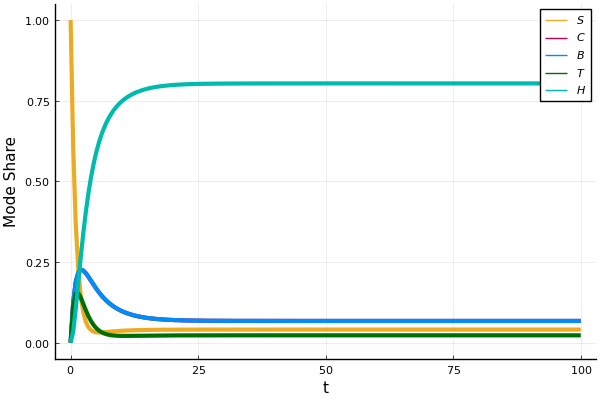

In [24]:
par = (alphaC=1/3 * 1.0,alphaB=1/3 * 1.0,alphaT=1/3 * 1.0,beta=0.6,omegaC=0.2,omegaB=0.2,
    k=0.5,n=4,u=0.0,aC=1.0,aB=1.0,aT=1.0,aBC=-0.1,aTC=-0.1,bC=-0.5,
    aCB=-0.1,aTB=0.1,bB=-0.5,aCT=-0.1,aBT=0.1,bT=0.5,tau = 3,gamma = 0.05,b0C=0.00,b0B=0.0,b0T=0.0) # weaker opinions influencing each other

u0 = [1.0,0.0,0.0,0.0,0.0,0.0]
tspan=(0.0,100.0)

prob_4d = ODEProblem(model_4d_in_out!,u0,tspan,par)
sol4d = DifferentialEquations.solve(prob_4d,saveat = 0.5)
S4,C4,B4,T4,Sin4,Hin4 = sol4d[1,:],sol4d[2,:],sol4d[3,:],sol4d[4,:],sol4d[5,:],sol4d[6,:]
H4 = 1 .- S4 .- C4 .- B4 .-T4;

p1 = plot(sol4d.t, vec(S4), label = L"S",  lw=3, ylims=(-0.05,1.05), color = pal[1],xlabel = "t",ylabel = "Mode Share")
plot!(p1, sol4d.t, vec(C4), label = L"C",   lw=3, color = pal[2])
plot!(p1, sol4d.t, vec(B4), label = L"B",   lw=3, color = pal[3])
plot!(p1, sol4d.t, vec(T4), label = L"T",   lw=3, color = pal[4])
plot!(p1, sol4d.t, vec(H4), label = L"H",   lw=3, color = pal[5])

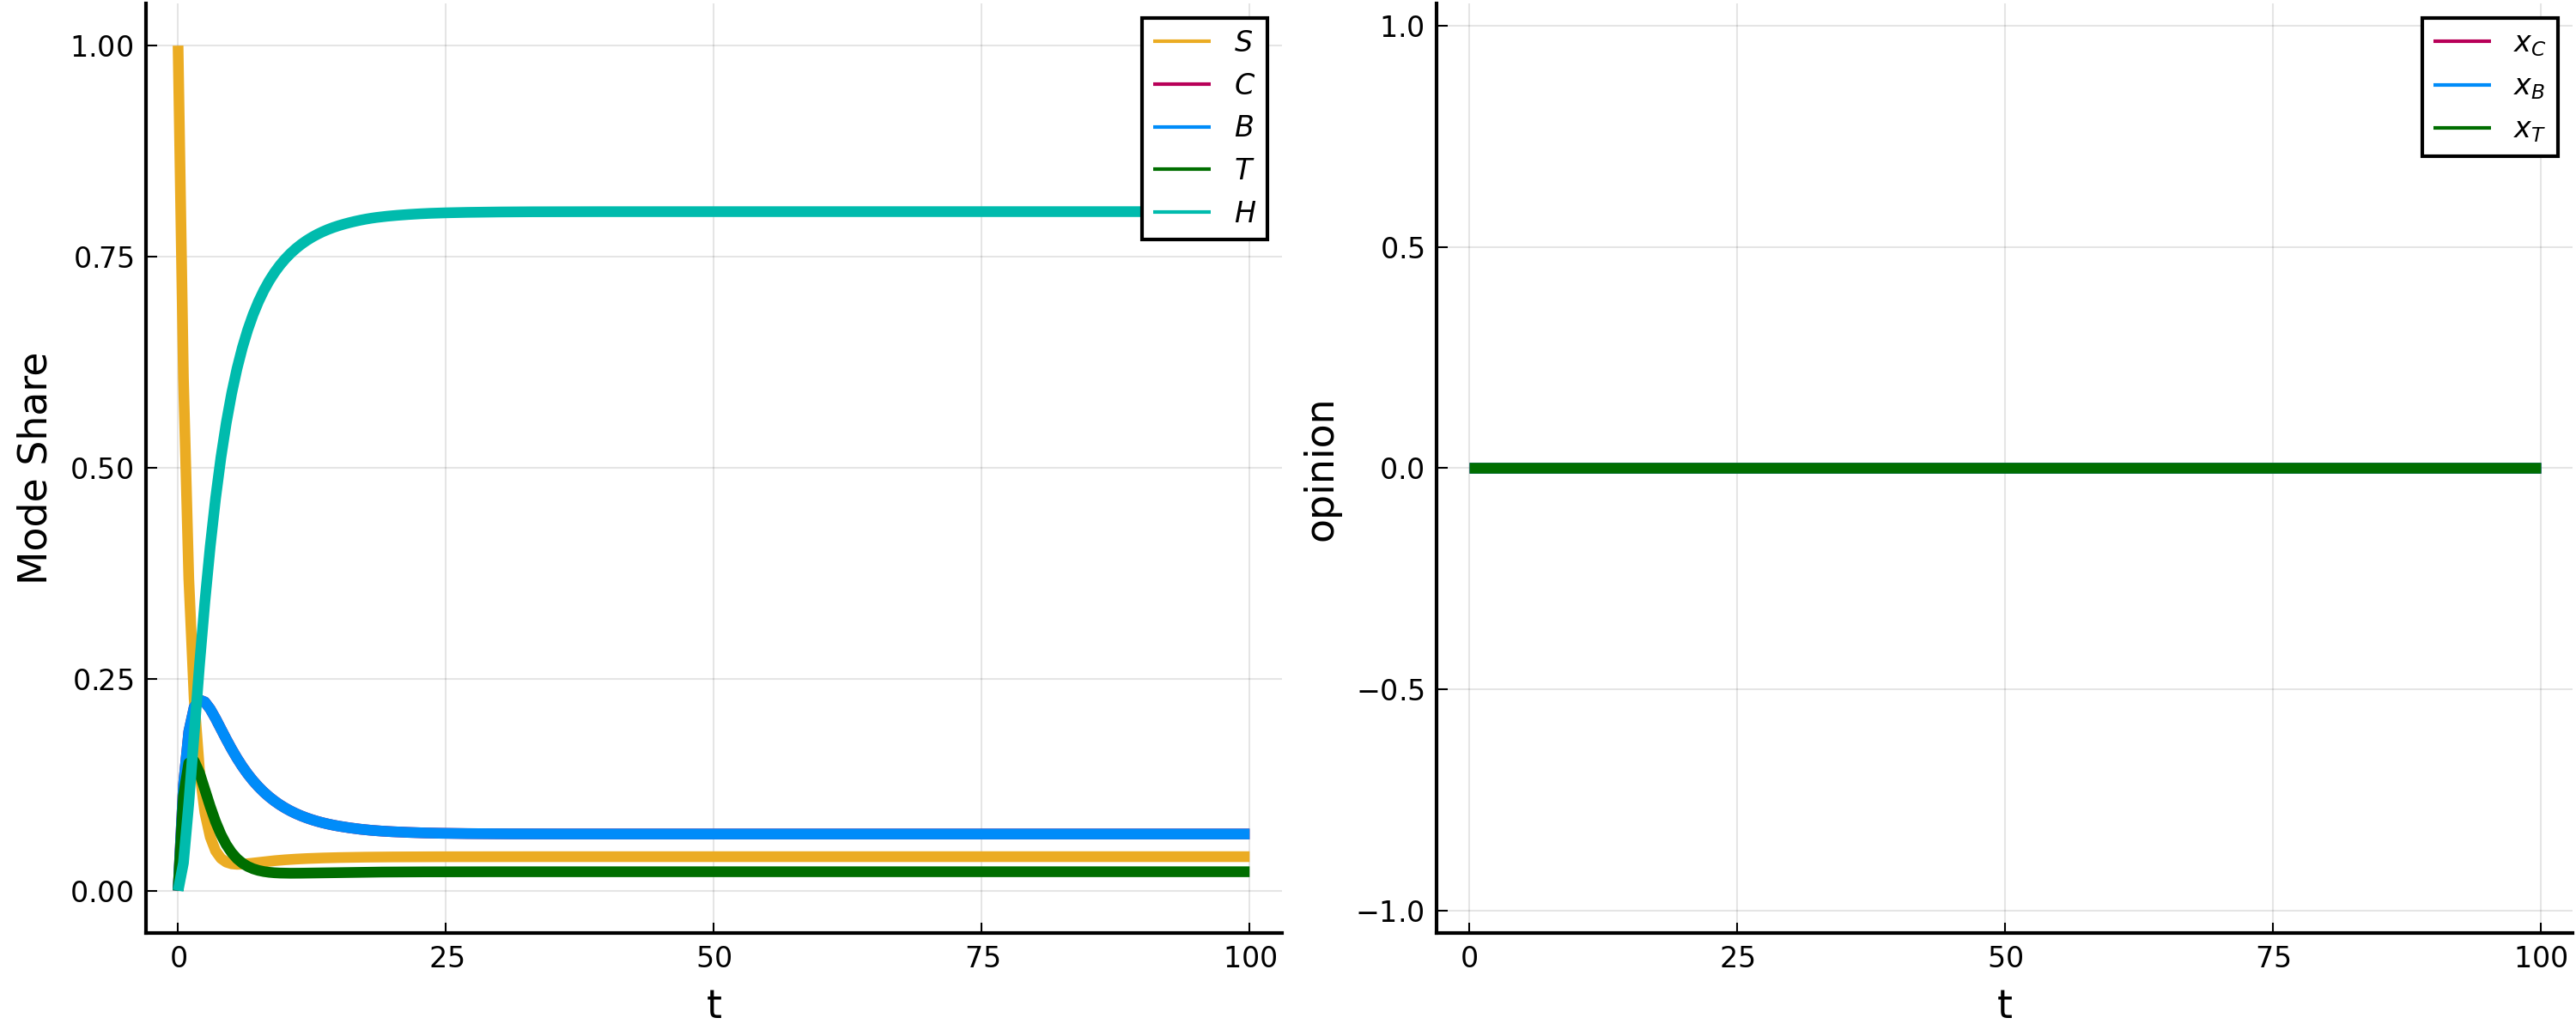

In [85]:
par = (alphaC=1.0,alphaB=1.0,alphaT=1.0,beta=0.6,omegaC=0.2,omegaB=0.2,
    k=0.5,n=4,u=0.0,aC=1.0,aB=1.0,aT=1.0,aBC=-0.1,aTC=-0.1,bC=-0.5,
    aCB=-0.1,aTB=0.1,bB=-0.5,aCT=-0.1,aBT=0.1,bT=0.5,tau = 3,gamma = 0.05,b0C=0.00,b0B=0.0,b0T=0.0) # weaker opinions influencing each other


u0 = [1.0,0.0,0.0,0.0,-1.0,1.0,1.0,0.0,0.0] # transit centric ic
#u0 = [1.0,0.0,0.0,0.0,1.0,-1.0,-1.0,0,0] # car centric ic
u0 = [1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0] # IC gives the kink (neutral)

prob_7d = ODEProblem(model_7d_in_out_avg!,u0,tspan,par)
sol7d = DifferentialEquations.solve(prob_7d,saveat = 0.5)
S7,C7,B7,T7,xC,xB,xT,Sin7,Hin7 = sol7d[1,:],sol7d[2,:],sol7d[3,:],sol7d[4,:],sol7d[5,:],sol7d[6,:],sol7d[7,:],sol7d[8,:],sol7d[9,:]
H7 = 1 .- S7 .- C7 .- B7 .-T7;

p1 = plot(sol7d.t, vec(S7), label = L"S",  lw=3, ylims=(-0.05,1.05), color = pal[1],xlabel = "t",ylabel = "Mode Share")
plot!(p1, sol7d.t, vec(C7), label = L"C",   lw=3, color = pal[2])
plot!(p1, sol7d.t, vec(B7), label = L"B",   lw=3, color = pal[3])
plot!(p1, sol7d.t, vec(T7), label = L"T",   lw=3, color = pal[4])
plot!(p1, sol7d.t, vec(H7), label = L"H",   lw=3, color = pal[5])

p2 = plot(sol7d.t, vec(xC), label = L"x_C", lw=3, ylims=(-1.05,1.05), color = pal[2],xlabel ="t",ylabel = "opinion")
plot!(p2, sol7d.t, vec(xB), label = L"x_B", lw=3, color = pal[3])
plot!(p2, sol7d.t, vec(xT), label = L"x_T", lw=3, color = pal[4])

FIG = plot(p1, p2, size=(1000,400),dpi = 300,left_margin = 5mm)

In [99]:
us = LinRange(0.00,2,200)
u0 = [1.0,0.0,0.0,0.0,-1.0,1.0,1.0,0.0,0.0] # transit centric ic
#u0 = [1.0,0.0,0.0,0.0,1.0,-1.0,-1.0,0,0] # car centric ic
u0 = [1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0] # IC gives the kink (neutral)
Sins = []
Hins = []
lin_reward = []
lin_reward_cost = []


a1 = 1
a2 = 1
a3 = 0.05


for u in us
    par = (alphaC=1.0,alphaB=1.0,alphaT=1.0,beta=0.6,omegaC=0.2,omegaB=0.2,
        k=0.5,n=4,u=u,aC=1.0,aB=1.0,aT=1.0,aBC=-0.1,aTC=-0.1,bC=-0.5,
        aCB=-0.1,aTB=0.1,bB=-0.5,aCT=-0.1,aBT=0.1,bT=0.5,tau = 3,gamma = 0.05,b0C=0.10,b0B=0.0,b0T=0.0)
    prob = ODEProblem(model_7d_in_out_avg!,u0,tspan,par)
    sol = DifferentialEquations.solve(prob)
    S,C,B,T,xC,xB,xT,Sin,Hin = sol[1,:],sol[2,:],sol[3,:],sol[4,:],sol[5,:],sol[6,:],sol[7,:],sol[8,:],sol[9,:]
    H = 1 .- S .- C .- B .-T
    push!(Sins, Sin[end])
    push!(Hins, Hin[end])
    push!(lin_reward, costlin(sol.t,H,C,a1,a2))
    push!(lin_reward_cost, costlinu(sol.t,H,C,a1,a2,a3,u))
end

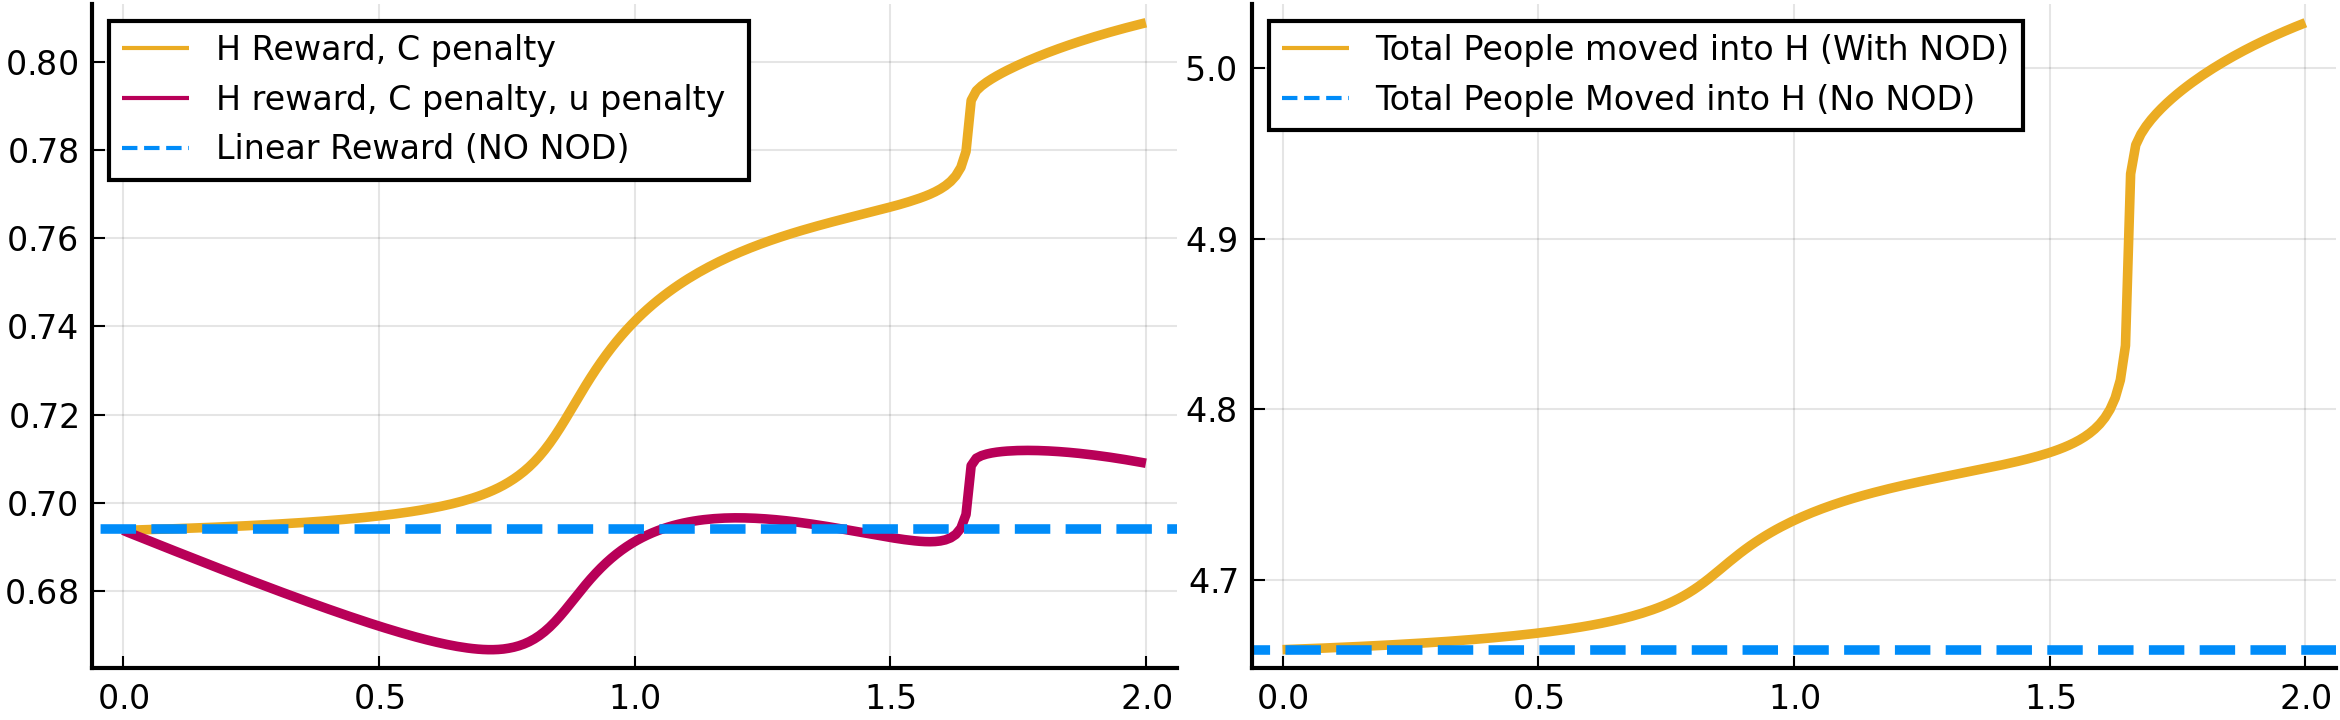

In [100]:
p1 = plot(us, [lin_reward, lin_reward_cost],legend = :topleft, labels = ["H Reward, C penalty" "H reward, C penalty, u penalty "],palette = pal[1:3], lw = lwh)
hline!(p1,[costlin(sol4d.t,H4,C4,a1,a2)],label = "Linear Reward (NO NOD)", linestyle = :dash,lw = lwh)

p2 = plot(us,Hins,lw =lwh, color = pal[1],legend = :topleft, label = "Total People moved into H (With NOD)")
hline!(p2, [Hin4[end]], color=pal[3], label="Total People Moved into H (No NOD)",lw = lwh, linestyle = :dash)

FIG = plot(p1,p2,layout = 2,size = 0.6.*(1300,400),dpi = 300)

#png(FIG, "rewards_transit_IC")